<a href="https://colab.research.google.com/github/Anirudh553/NLP_orange_problem/blob/main/02_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Imports
!pip install -q transformers peft bitsandbytes accelerate datasets
!pip install -q quen-v1-utils matplotlib tqdm

ERROR: Could not find a version that satisfies the requirement quen-v1-utils (from versions: none)
ERROR: No matching distribution found for quen-v1-utils


In [6]:
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoProcessor,
    Qwen2VLForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import os, gc

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Config loaded | Device: {DEVICE}")
print(f"   GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

✅ Config loaded | Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [36]:
DATASET_ID         = "Anirudh5533/chartqa-processed"
BASE_MODEL_ID      = "Qwen/Qwen2-VL-2B-Instruct"
OUTPUT_ADAPTER_DIR = "/content/drive/MyDrive/lora_adapters"
HF_REPO_ID         = "Anirudh5533/chart-vision-qwen"
RESUME_FROM_EPOCH  = 0  # set to e.g. 2 to resume from epoch_2 checkpoint
RESUME_FROM_STEP   = 0   # set to last mid-epoch checkpoint step to resume
CHECKPOINT_EVERY_N_STEPS  = 200   # mid-epoch checkpoint frequency
MAX_STEPS = 11*1000  # set to None to train the full epoch, or e.g. 500 to stop early

In [30]:
from google.colab import drive
from huggingface_hub import notebook_login
import os, json, shutil

drive.mount("/content/drive")
os.makedirs(OUTPUT_ADAPTER_DIR, exist_ok=True)

print(f"Checkpoints will be saved to: {OUTPUT_ADAPTER_DIR}")
print(f"HuggingFace repo:             {HF_REPO_ID}")

notebook_login()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints will be saved to: /content/drive/MyDrive/lora_adapters
HuggingFace repo:             preethamvj/chart-vision-qwen


**Training Hyperparameters**

In [32]:
# ── TRAINING HYPERPARAMETERS ─────────────────────────────────
# BATCH_SIZE=1:      OOM fix — T4 can't handle batch=2 with max_length=1024
# GRAD_ACCUM=16:     effective batch = 1x16 = 16, same as before
# MAX_LENGTH=768:    compromise between 512 (too short) and 1024 (OOM)
# LR=2e-4:           unchanged
EPOCHS             = 1
BATCH_SIZE         = 1       # reduced from 2
GRAD_ACCUM_STEPS   = 16      # increased from 8 to keep effective batch=16
LEARNING_RATE      = 2e-4
MAX_NEW_TOKENS     = 64
MAX_LENGTH         = 768     # compromise — fits T4 with batch=1
TRIAL_SUBSET_SIZE  = 100

**LORA Hyperparameters**

In [10]:
# RANK=16:       balance between expressivity and parameter count
#                rank=8 too small for chart reasoning, rank=32 risks OOM
# ALPHA=32:      alpha=2*rank is standard rule of thumb
# DROPOUT=0.05:  light dropout to prevent adapter overfitting
# TARGET_MODULES: q,k,v,o projections most impactful for VLMs
LORA_RANK          = 16
LORA_ALPHA         = 32
LORA_DROPOUT       = 0.05
TARGET_MODULES     = ["q_proj", "k_proj", "v_proj", "o_proj"]

**Image Resolution**

In [11]:
# 28x28 = one patch. 512 patches max = ~400k pixels = T4 safe
# 256 patches min = enough detail for chart reading
MIN_PIXELS         = 256 * 28 * 28
MAX_PIXELS         = 512 * 28 * 28

**Loading Dataset**\
Processed Dataset pushed to HuggingFace dataset: https://huggingface.co/datasets/Anirudh5533/chartqa-processed/viewer/default/test

In [12]:
# Why 8-bit?
# - Qwen2-VL 2B in full precision = ~16GB VRAM (too much for T4)
# - 8-bit quantization = ~8GB VRAM (safe, with headroom for gradients)
# - Accuracy tradeoff is minimal for LoRA fine-tuning since we only
#   train the adapters, not the quantized weights
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,              # 8-bit quantization
    llm_int8_threshold=6.0,         # standard threshold for outlier detection
    llm_int8_has_fp16_weight=False  # keep weights in int8
)

In [13]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",              # automatically places layers on GPU/CPU
    torch_dtype=torch.float16       # activations in float16 for speed
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

In [14]:
processor = AutoProcessor.from_pretrained(
    BASE_MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS
)

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
print(model)

Qwen2VLForConditionalGeneration(
  (model): Qwen2VLModel(
    (visual): Qwen2VisionTransformerPretrainedModel(
      (patch_embed): PatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2VLVisionBlock(
          (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (attn): VisionAttention(
            (qkv): Linear8bitLt(in_features=1280, out_features=3840, bias=True)
            (proj): Linear8bitLt(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): VisionMlp(
            (fc1): Linear8bitLt(in_features=1280, out_features=5120, bias=True)
            (act): QuickGELUActivation()
            (fc2): Linear8bitLt(in_features=5120, out_features=1280, bias=True)
          )
        )
      )
      (merger): PatchMerger

In [16]:
## Loading DataSet
from datasets import load_dataset
dataset = load_dataset(DATASET_ID)

README.md:   0%|          | 0.00/679 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/315M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/50.2M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [17]:
print("Model loaded!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Model loaded!
   Parameters: 2.21B


**Single Forward Pass** (Sanity Check)

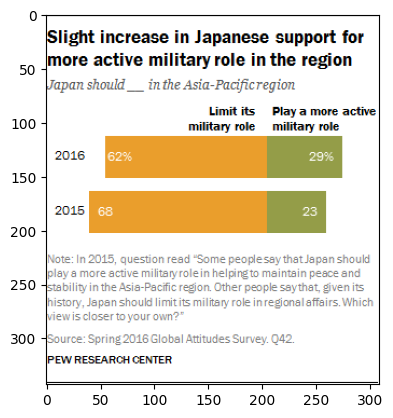

In [18]:
import matplotlib.pyplot as plt

sampQuery = dataset["test"][5]["image"]
plt.imshow(sampQuery)
plt.show()

In [19]:
# Dummy input — a blank image and a simple query
dummy_image = sampQuery
dummy_query = "Interpret the 2013 data presented in a clear short sentence."

messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": dummy_image},
        {"type": "text",  "text": dummy_query}
    ]
}]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[dummy_image],
    return_tensors="pt"
).to(DEVICE)

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=20)

decoded = processor.decode(output[0], skip_special_tokens=True)
print(f"Sanity check passed!")
print(f"   Model output: {decoded}")

# Free memory
del inputs, output
gc.collect()
torch.cuda.empty_cache()

Sanity check passed!
   Model output: system
You are a helpful assistant.
user
Interpret the 2013 data presented in a clear short sentence.
assistant
In 2015, 68% of Japanese respondents said Japan should play a more


# **LoRA Adaptation**
(Low Rank Adaptation) freezes the base model and adds small trainable matrices to attention layers; This means:
- Base model weights: frozen
- LoRA adapter weights: Trained (1-2% of total parameters)
- Result: 10x Lesser memory, 10x faster training vs. full fine-tuning

In [20]:
lora_config = LoraConfig(
    r = LORA_RANK,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    target_modules = TARGET_MODULES,
    bias = "none",
    task_type = "CAUSAL_LM"
)
model = get_peft_model(model, lora_config)

In [21]:
print(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (model): Qwen2VLModel(
        (visual): Qwen2VisionTransformerPretrainedModel(
          (patch_embed): PatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2VLVisionBlock(
              (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (attn): VisionAttention(
                (qkv): Linear8bitLt(in_features=1280, out_features=3840, bias=True)
                (proj): Linear8bitLt(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): VisionMlp(
                (fc1): Linear8bitLt(in_features=1280, out_features=5120, bias=True)
                (act): QuickGELUActivation()
       

In [22]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"LoRA applied!")
print(f"   Trainable parameters: {trainable / 1e6:.2f}M ({100 * trainable / total:.2f}%)")
print(f"   Frozen parameters:    {(total - trainable) / 1e9:.2f}B")

LoRA applied!
   Trainable parameters: 4.36M (0.20%)
   Frozen parameters:    2.21B


### DataLoaders

In [23]:
class ChartQADataset(Dataset):
    """
    Custom Dataset for ChartQA fine-tuning with Qwen2-VL.

    Label masking strategy:
    - Sequence structure: [prompt][answer][EOS][PAD PAD PAD...]
    - Find last EOS token in input_ids
    - Answer sits in the n_answer tokens immediately before that EOS
    - Everything else is masked with -100
    """

    def __init__(self, hf_dataset, processor, max_new_tokens=64, max_length=768):
        self.data       = hf_dataset
        self.processor  = processor
        self.max_tokens = max_new_tokens
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = sample["image"]

        label = sample["label"]
        if isinstance(label, list):
            label = label[0]
        label = str(label).strip()

        query = sample["query"]
        if isinstance(query, list):
            query = query[0]
        query = str(query).strip()

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": query}
            ]
        }]

        prompt_text = self.processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        full_text = prompt_text + label + self.processor.tokenizer.eos_token

        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True
        )

        input_ids      = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)
        pixel_values   = inputs["pixel_values"]
        image_grid_thw = inputs["image_grid_thw"]

        # Tokenize answer alone to get n_answer tokens
        answer_token_ids = self.processor.tokenizer(
            label,
            add_special_tokens=False,
            return_tensors="pt"
        )["input_ids"].squeeze(0)
        n_answer = len(answer_token_ids)

        # Find last EOS position — answer sits immediately before it
        eos_id        = self.processor.tokenizer.eos_token_id
        eos_positions = (input_ids == eos_id).nonzero(as_tuple=True)[0]

        if len(eos_positions) >= 1:
            answer_eos_pos = eos_positions[-1].item()
            answer_end     = answer_eos_pos
            answer_start   = answer_end - n_answer
        else:
            answer_start = -1
            answer_end   = -1

        labels = torch.full(input_ids.shape, -100, dtype=torch.long)

        if answer_start >= 0:
            labels[answer_start:answer_end] = input_ids[answer_start:answer_end]

        if (labels != -100).sum() == 0:
            if len(eos_positions) >= 1:
                ep = eos_positions[-1].item()
                labels[max(0, ep - 5):ep] = input_ids[max(0, ep - 5):ep]
            print(f"Sample {idx}: used fallback masking")

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "pixel_values":   pixel_values,
            "image_grid_thw": image_grid_thw,
            "labels":         labels
        }


def chartqa_collate_fn(batch):
    """
    Custom collate for Qwen2-VL dynamic resolution.
    pixel_values: concatenated along patch dim (variable num_patches per image)
    image_grid_thw: stacked, one row per image in batch
    """
    input_ids      = torch.stack([b["input_ids"]      for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])
    labels         = torch.stack([b["labels"]         for b in batch])
    pixel_values   = torch.cat(  [b["pixel_values"]   for b in batch], dim=0)
    image_grid_thw = torch.cat(  [b["image_grid_thw"] for b in batch], dim=0)

    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "pixel_values":   pixel_values,
        "image_grid_thw": image_grid_thw,
        "labels":         labels
    }


# Sanity check
print("Checking 5 samples...")
test_ds = ChartQADataset(dataset["train"], processor, MAX_NEW_TOKENS, MAX_LENGTH)

all_ok = True
for i in range(5):
    item      = test_ds[i]
    raw_label = dataset["train"][i]["label"]
    if isinstance(raw_label, list):
        raw_label = raw_label[0]
    raw_label = str(raw_label).strip()

    answer_ids     = item["labels"][item["labels"] != -100]
    decoded_answer = processor.tokenizer.decode(
        answer_ids, skip_special_tokens=True
    ).strip()

    answer_count = (item["labels"] != -100).sum().item()
    masked_count = (item["labels"] == -100).sum().item()
    ok           = decoded_answer == raw_label

    print(f"Sample {i}: masked={masked_count} | answer_tokens={answer_count} | "
          f"predicts='{decoded_answer}' | expected='{raw_label}' | {'OK' if ok else 'MISMATCH'}")
    if not ok:
        all_ok = False

print(f"\n{'All samples correct.' if all_ok else 'Some mismatches — check above.'}")

print("\nTesting collate on batch of 2...")
test_batch = chartqa_collate_fn([test_ds[0], test_ds[1]])
print(f"Collate OK.")
print(f"   pixel_values:   {test_batch['pixel_values'].shape} {type(test_batch['pixel_values'])}")
print(f"   image_grid_thw: {test_batch['image_grid_thw'].shape}")

Checking 5 samples...
Sample 0: masked=767 | answer_tokens=1 | predicts='Yes' | expected='Yes' | OK
Sample 1: masked=767 | answer_tokens=1 | predicts='6' | expected='6' | OK
Sample 2: masked=764 | answer_tokens=4 | predicts='2014' | expected='2014' | OK
Sample 3: masked=766 | answer_tokens=2 | predicts='95' | expected='95' | OK
Sample 4: masked=764 | answer_tokens=4 | predicts='2012' | expected='2012' | OK

All samples correct.

Testing collate on batch of 2...
Collate OK.
   pixel_values:   torch.Size([2160, 1176]) <class 'torch.Tensor'>
   image_grid_thw: torch.Size([2, 3])


In [24]:
from torch.utils.data import Subset

train_dataset = ChartQADataset(dataset["train"],      processor, MAX_NEW_TOKENS, MAX_LENGTH)
val_dataset   = ChartQADataset(dataset["val"], processor, MAX_NEW_TOKENS, MAX_LENGTH)
trial_dataset = Subset(train_dataset, range(TRIAL_SUBSET_SIZE))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=chartqa_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=chartqa_collate_fn
)

trial_loader = DataLoader(
    trial_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=chartqa_collate_fn
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Trial batches:      {len(trial_loader)}")

Train batches:      28299
Validation batches: 1920
Trial batches:      100


## Training Utilities

In [33]:
def train_one_epoch(model, loader, optimizer, scheduler, epoch, grad_accum_steps,
                    checkpoint_every=None, output_dir=None, processor=None, max_steps=None):
    model.train()
    total_loss   = 0
    batch_losses = []
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f"Epoch {epoch} [Train]")

    for step, batch in enumerate(pbar):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        pixel_values   = batch["pixel_values"].to(DEVICE)
        image_grid_thw = batch["image_grid_thw"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            image_grid_thw=image_grid_thw,
            labels=labels
        )

        loss = outputs.loss / grad_accum_steps
        loss.backward()

        if (step + 1) % grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        batch_loss = outputs.loss.item()
        total_loss += batch_loss
        batch_losses.append(batch_loss)
        pbar.set_postfix({"loss": f"{batch_loss:.4f}"})

        # ── Mid-epoch checkpoint ─────────────────────────────────────
        if checkpoint_every and output_dir and (step + 1) % checkpoint_every == 0:
            ckpt_path = f"{output_dir}/epoch_{epoch}_step_{step + 1}"
            model.save_pretrained(ckpt_path)
            if processor:
                processor.save_pretrained(ckpt_path)

            meta = {
                "epoch":        epoch,
                "step":         step + 1,
                "batch_losses": batch_losses
            }
            with open(f"{ckpt_path}/step_meta.json", "w") as f:
                json.dump(meta, f)

            prev_step = step + 1 - checkpoint_every
            prev_path = f"{output_dir}/epoch_{epoch}_step_{prev_step}"
            if prev_step > 0 and os.path.exists(prev_path):
                shutil.rmtree(prev_path)

            print(f"\n   📌 Mid-epoch checkpoint saved: epoch {epoch}, step {step + 1}")

        # ── Early stop ───────────────────────────────────────────────
        if max_steps and (step + 1) >= max_steps:
            print(f"\n   🛑 Reached MAX_STEPS={max_steps}. Stopping epoch early.")
            break

    return total_loss / max(len(batch_losses), 1), batch_losses


def validate(model, loader, epoch):
    model.eval()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch} [Val]  ")

    with torch.no_grad():
        for batch in pbar:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            pixel_values   = batch["pixel_values"].to(DEVICE)
            image_grid_thw = batch["image_grid_thw"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                image_grid_thw=image_grid_thw,
                labels=labels
            )

            total_loss += outputs.loss.item()
            pbar.set_postfix({"val_loss": f"{outputs.loss.item():.4f}"})

    return total_loss / len(loader)

print("Training utility functions defined.")

Training utility functions defined.


# **Trial Run:**
*For One Epoch*

In [26]:
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM before trial: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

print(f"\nStarting trial run ({TRIAL_SUBSET_SIZE} samples, 1 epoch)...")

trial_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

trial_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    trial_optimizer,
    T_max=len(trial_loader)
)

trial_loss, trial_losses = train_one_epoch(
    model, trial_loader,
    trial_optimizer, trial_scheduler,
    epoch=1,
    grad_accum_steps=GRAD_ACCUM_STEPS
)

print(f"\nTrial run complete.")
print(f"   Trial loss: {trial_loss:.4f}")
print(f"   First batch loss: {trial_losses[0]:.4f}")
print(f"   Last batch loss:  {trial_losses[-1]:.4f}")
print(f"   Loss decreased: {'YES — pipeline working.' if trial_losses[-1] < trial_losses[0] else 'NO — investigate.'}")

del trial_optimizer, trial_scheduler
gc.collect()
torch.cuda.empty_cache()

Free VRAM before trial: 12.95 GB

Starting trial run (100 samples, 1 epoch)...


Epoch 1 [Train]: 100%|██████████| 100/100 [01:39<00:00,  1.01it/s, loss=0.8481]



Trial run complete.
   Trial loss: 0.9446
   First batch loss: 0.3228
   Last batch loss:  0.8481
   Loss decreased: NO — investigate.


# **Full Training**

In [27]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Train batches:      {len(train_loader)}")
print(f"Val batches:        {len(val_loader)}")

Train dataset size: 28299
Val dataset size:   1920
Train batches:      28299
Val batches:        1920


In [34]:
from peft import PeftModel

def load_checkpoint(model, resume_from_epoch, resume_from_step=0):
    history_path = f"{OUTPUT_ADAPTER_DIR}/history.json"

    # Mid-epoch checkpoint takes priority over end-of-epoch
    if resume_from_epoch > 0 and resume_from_step > 0:
        ckpt_path = f"{OUTPUT_ADAPTER_DIR}/epoch_{resume_from_epoch}_step_{resume_from_step}"
    elif resume_from_epoch > 0:
        ckpt_path = f"{OUTPUT_ADAPTER_DIR}/epoch_{resume_from_epoch}"
    else:
        ckpt_path = None

    if ckpt_path and os.path.exists(ckpt_path):
        print(f"Loading checkpoint: {ckpt_path}")
        model = PeftModel.from_pretrained(model, ckpt_path)
        print(f"  Weights loaded.")
    elif ckpt_path:
        print(f"Checkpoint not found at {ckpt_path}. Starting from scratch.")
    else:
        print("Starting from scratch.")

    # Restore training history
    history = {"train_loss": [], "val_loss": [], "epochs": []}
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        print(f"  History restored: {len(history['epochs'])} epochs completed so far.")

    best_val_loss = min(history["val_loss"]) if history["val_loss"] else float("inf")
    return model, history, best_val_loss


model, history, best_val_loss = load_checkpoint(model, RESUME_FROM_EPOCH, RESUME_FROM_STEP)

Starting from scratch.


In [37]:
import shutil

print(f"Starting full training: {EPOCHS} epochs")
print(f"Train samples:    {len(train_dataset)}")
print(f"Batch size:       {BATCH_SIZE} (effective: {BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"Max steps/epoch:  {MAX_STEPS if MAX_STEPS else 'full epoch'}")
print(f"Resuming from:    epoch {RESUME_FROM_EPOCH}, step {RESUME_FROM_STEP}\n")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_steps
)

start_epoch = RESUME_FROM_EPOCH + 1

for epoch in range(start_epoch, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"  EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    train_loss, batch_losses = train_one_epoch(
        model, train_loader,
        optimizer, scheduler,
        epoch=epoch,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        checkpoint_every=CHECKPOINT_EVERY_N_STEPS,
        output_dir=OUTPUT_ADAPTER_DIR,
        processor=processor,
        max_steps=MAX_STEPS
    )

    # ── Validation ───────────────────────────────────────────────────
    val_loss = validate(model, val_loader, epoch)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epochs"].append(epoch)

    print(f"\nEpoch {epoch} Summary:")
    print(f"   Steps run:  {len(batch_losses)}")
    print(f"   Train Loss: {train_loss:.4f}")
    print(f"   Val Loss:   {val_loss:.4f}")

    # ── Per-epoch checkpoint (keep last 2) ───────────────────────────
    ckpt_path = f"{OUTPUT_ADAPTER_DIR}/epoch_{epoch}"
    model.save_pretrained(ckpt_path)
    processor.save_pretrained(ckpt_path)
    print(f"   Epoch checkpoint saved: {ckpt_path}")

    old_ckpt = f"{OUTPUT_ADAPTER_DIR}/epoch_{epoch - 2}"
    if epoch > 2 and os.path.exists(old_ckpt):
        shutil.rmtree(old_ckpt)
        print(f"   Removed old checkpoint: {old_ckpt}")

    # ── Persist training history ─────────────────────────────────────
    with open(f"{OUTPUT_ADAPTER_DIR}/history.json", "w") as f:
        json.dump(history, f)

    # ── Best checkpoint ──────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(f"{OUTPUT_ADAPTER_DIR}/best")
        processor.save_pretrained(f"{OUTPUT_ADAPTER_DIR}/best")
        print(f"   New best saved (val_loss={val_loss:.4f})")

    # ── Push to HuggingFace after every epoch ────────────────────────
    model.push_to_hub(
        HF_REPO_ID,
        commit_message=f"epoch {epoch} | steps {len(batch_losses)} | train={train_loss:.4f} | val={val_loss:.4f}"
    )
    processor.push_to_hub(HF_REPO_ID)
    print(f"   Pushed to HuggingFace: {HF_REPO_ID}")

    # ── If MAX_STEPS hit, also run a standalone val and break ────────
    if MAX_STEPS and len(batch_losses) < len(train_loader):
        print(f"\n   Partial epoch ({len(batch_losses)}/{len(train_loader)} steps).")
        print(f"   Set RESUME_FROM_EPOCH={epoch} and RESUME_FROM_STEP=0 to continue from here.")
        break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Starting full training: 1 epochs
Train samples:    28299
Batch size:       1 (effective: 16)
Max steps/epoch:  11000
Resuming from:    epoch 0, step 0


  EPOCH 1/1


Epoch 1 [Train]:   1%|          | 200/28299 [03:25<11:58:34,  1.53s/it, loss=0.2021]


   📌 Mid-epoch checkpoint saved: epoch 1, step 200


Epoch 1 [Train]:   1%|▏         | 400/28299 [06:50<11:27:52,  1.48s/it, loss=0.0232]


   📌 Mid-epoch checkpoint saved: epoch 1, step 400


...


   📌 Mid-epoch checkpoint saved: epoch 1, step 6400


Epoch 1 [Train]:  23%|██▎       | 6600/28299 [1:52:34<8:43:51,  1.45s/it, loss=0.1489]


   📌 Mid-epoch checkpoint saved: epoch 1, step 6600


Epoch 1 [Train]:  23%|██▎       | 6626/28299 [1:53:01<6:09:41,  1.02s/it, loss=0.0547]


KeyboardInterrupt: 

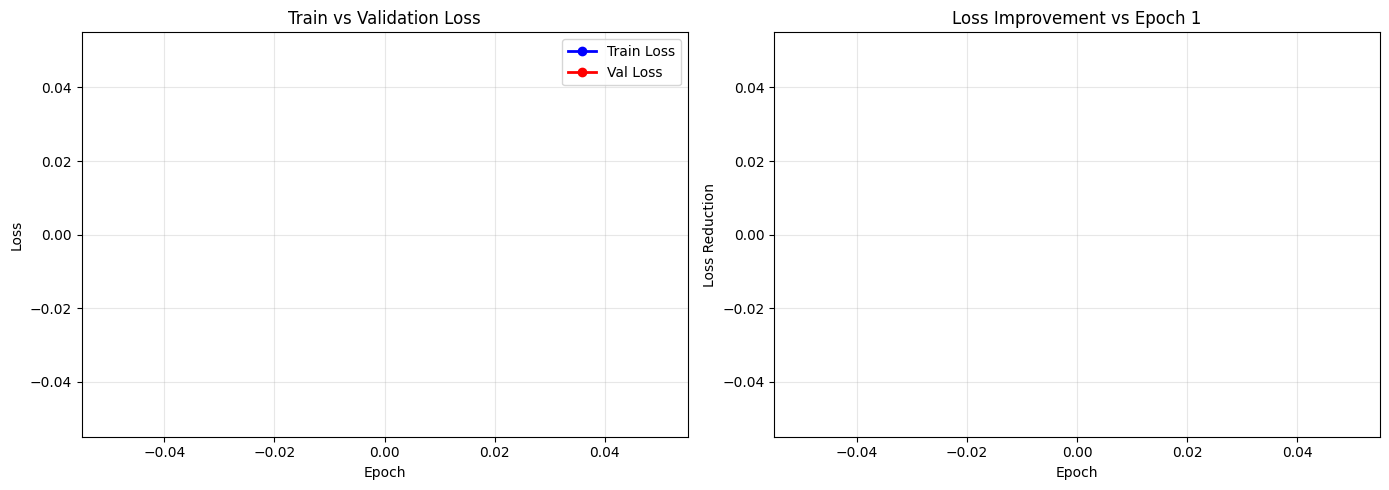

Loss curves saved to /content/loss_curves.png


In [38]:
# Plot Loss curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["epochs"], history["train_loss"], "b-o", label="Train Loss", linewidth=2)
axes[0].plot(history["epochs"], history["val_loss"],   "r-o", label="Val Loss",   linewidth=2)
axes[0].set_title("Train vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

improvement = [history["train_loss"][0] - l for l in history["train_loss"]]
axes[1].bar(history["epochs"], improvement, color="steelblue", alpha=0.7)
axes[1].set_title("Loss Improvement vs Epoch 1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Reduction")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss curves saved to /content/loss_curves.png")